In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "data_output"

store_master = pd.read_csv(f"{DATA_PATH}/store_master.csv")
product_master_parent = pd.read_csv(f"{DATA_PATH}/product_master_parent.csv")
product_master_child = pd.read_csv(f"{DATA_PATH}/product_master_child.csv")
weekly_sales_fact = pd.read_csv(f"{DATA_PATH}/weekly_sales_fact.csv")
replen_support_table = pd.read_csv(f"{DATA_PATH}/replen_support_table.csv")

# Convert date
weekly_sales_fact["week_start_date"] = pd.to_datetime(weekly_sales_fact["week_start_date"])

In [2]:
print("Shape:", weekly_sales_fact.shape)
print("Null check:")
print(weekly_sales_fact.isnull().sum())

print("\nSales distribution:")
print(weekly_sales_fact["sales_qty"].describe())

Shape: (780, 13)
Null check:
week_id            0
week_start_date    0
week_end_date      0
week_type          0
store_id           0
store_name         0
parent_sku_id      0
child_sku_id       0
lifecycle_type     0
base_price         0
sales_qty          0
sales_value        0
has_sales          0
dtype: int64

Sales distribution:
count    780.000000
mean       0.174359
std        0.713241
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        5.000000
Name: sales_qty, dtype: float64


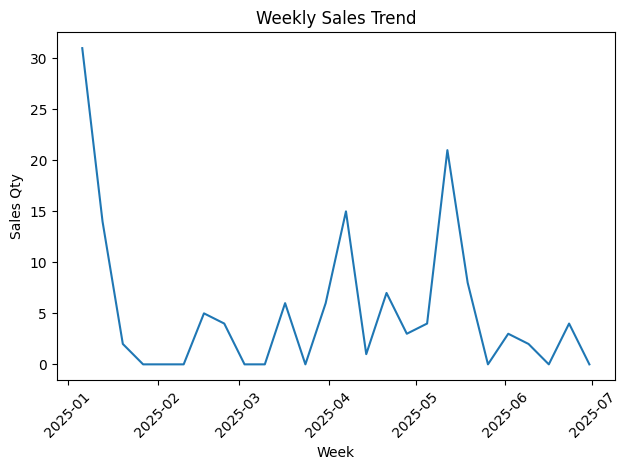

In [3]:
weekly_trend = (
    weekly_sales_fact.groupby(["week_start_date", "week_type"])["sales_qty"]
    .sum()
    .reset_index()
)

plt.figure()
plt.plot(weekly_trend["week_start_date"], weekly_trend["sales_qty"])

plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Sales Qty")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
promo_calendar = pd.read_csv(f"{DATA_PATH}/promo_calendar.csv")
promo_calendar["week_start_date"] = pd.to_datetime(promo_calendar["week_start_date"])
promo_calendar["week_end_date"] = pd.to_datetime(promo_calendar["week_end_date"])

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# make sure dates are datetime
weekly_sales_fact["week_start_date"] = pd.to_datetime(weekly_sales_fact["week_start_date"])
promo_calendar["week_start_date"] = pd.to_datetime(promo_calendar["week_start_date"])

# aggregate weekly sales by store
weekly_store_trend = (
    weekly_sales_fact.groupby(["week_start_date", "store_name"], as_index=False)["sales_qty"]
    .sum()
)

weekly_store_trend.head()

,week_start_date,store_name,sales_qty
0,2025-01-06,Downtown Store,13
1,2025-01-06,Urban Store,18
2,2025-01-13,Downtown Store,14
3,2025-01-13,Urban Store,0
4,2025-01-20,Downtown Store,0


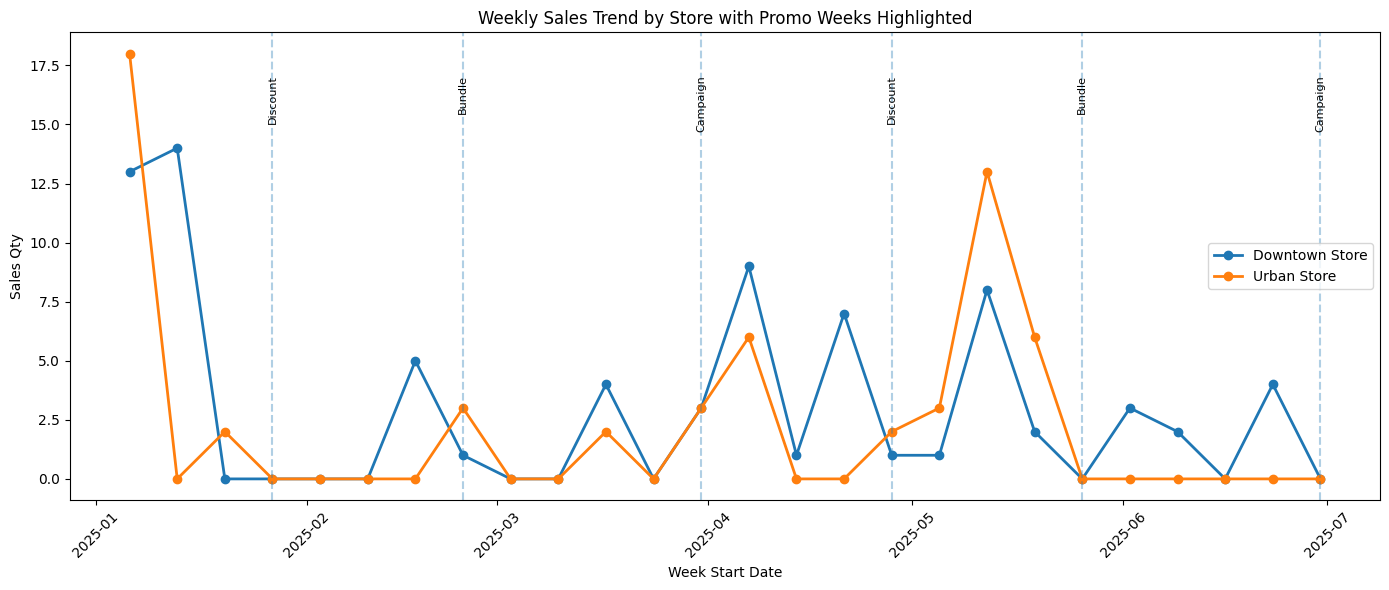

In [27]:
# pivot for line chart
plot_df = weekly_store_trend.pivot(
    index="week_start_date",
    columns="store_name",
    values="sales_qty"
).fillna(0)

# promo weeks that overlap sales period only
promo_plot_df = promo_calendar[promo_calendar["in_sales_period"] == 1].copy()
promo_plot_df = promo_plot_df[promo_plot_df["is_promo"] == 1].copy()

plt.figure(figsize=(14, 6))

# store lines
for store_name in plot_df.columns:
    plt.plot(
        plot_df.index,
        plot_df[store_name],
        marker="o",
        linewidth=2,
        label=store_name
    )

# promo vertical markers
y_max = plot_df.max().max()

for _, row in promo_plot_df.iterrows():
    promo_date = row["week_start_date"]
    promo_type = row["promo_type"]
    
    plt.axvline(
        x=promo_date,
        linestyle="--",
        alpha=0.35
    )
    
    plt.text(
        promo_date,
        y_max * 0.95,
        promo_type,
        rotation=90,
        va="top",
        ha="center",
        fontsize=8
    )

plt.title("Weekly Sales Trend by Store with Promo Weeks Highlighted")
plt.xlabel("Week Start Date")
plt.ylabel("Sales Qty")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

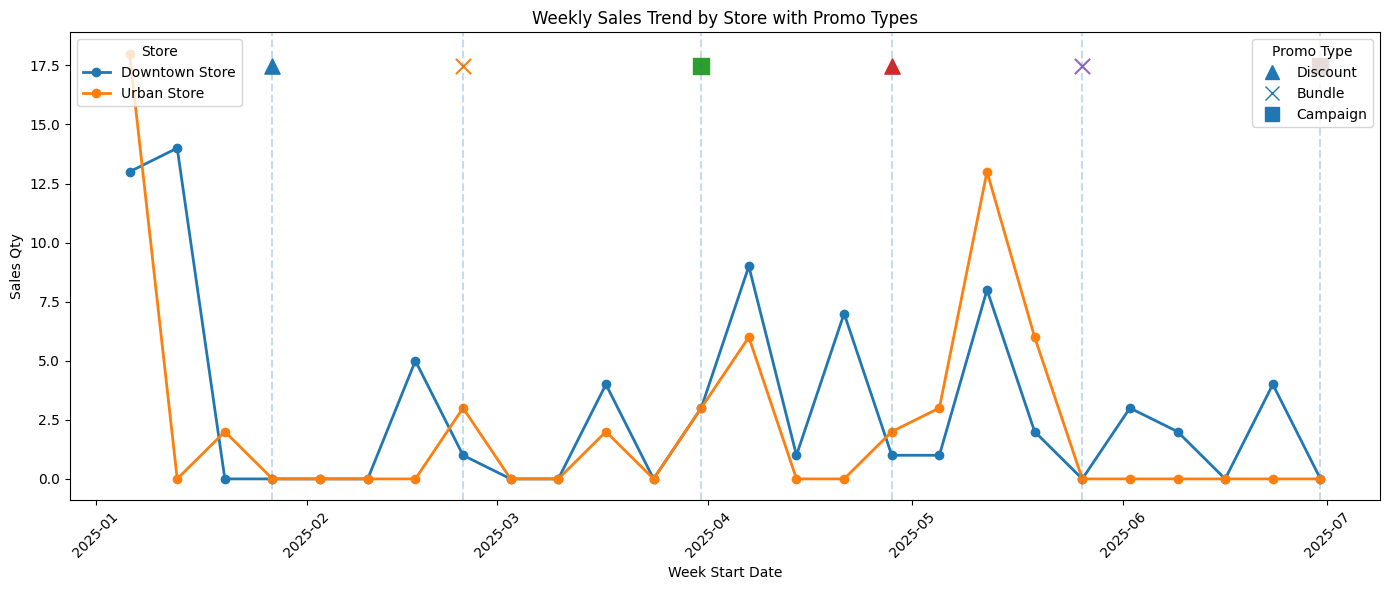

In [29]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# pivot
plot_df = weekly_store_trend.pivot(
    index="week_start_date",
    columns="store_name",
    values="sales_qty"
).fillna(0)

promo_plot_df = promo_calendar[
    (promo_calendar["in_sales_period"] == 1) &
    (promo_calendar["is_promo"] == 1)
].copy()

# -----------------------------
# Marker mapping
# -----------------------------
promo_marker_map = {
    "Discount": "^",   # triangle
    "Bundle": "x",     # cross
    "Campaign": "s"    # square
}

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(14, 6))

# store lines
for store_name in plot_df.columns:
    plt.plot(
        plot_df.index,
        plot_df[store_name],
        marker="o",
        linewidth=2,
        label=store_name
    )

y_max = plot_df.max().max()

# -----------------------------
# Promo markers
# -----------------------------
for _, row in promo_plot_df.iterrows():
    promo_date = row["week_start_date"]
    promo_type = row["promo_type"]
    marker_style = promo_marker_map.get(promo_type, "o")

    # vertical line
    plt.axvline(
        x=promo_date,
        linestyle="--",
        alpha=0.25
    )

    # marker
    plt.scatter(
        promo_date,
        y_max * 0.97,
        marker=marker_style,
        s=120
    )

# -----------------------------
# Legends
# -----------------------------

# Store legend (existing)
store_legend = plt.legend(title="Store", loc="upper left")

# Promo legend (custom)
promo_legend_elements = [
    Line2D([0], [0], marker="^", linestyle="None", label="Discount", markersize=10),
    Line2D([0], [0], marker="x", linestyle="None", label="Bundle", markersize=10),
    Line2D([0], [0], marker="s", linestyle="None", label="Campaign", markersize=10),
]

plt.legend(
    handles=promo_legend_elements,
    title="Promo Type",
    loc="upper right"
)

# keep both legends
plt.gca().add_artist(store_legend)

# -----------------------------
# Final touches
# -----------------------------
plt.title("Weekly Sales Trend by Store with Promo Types")
plt.xlabel("Week Start Date")
plt.ylabel("Sales Qty")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

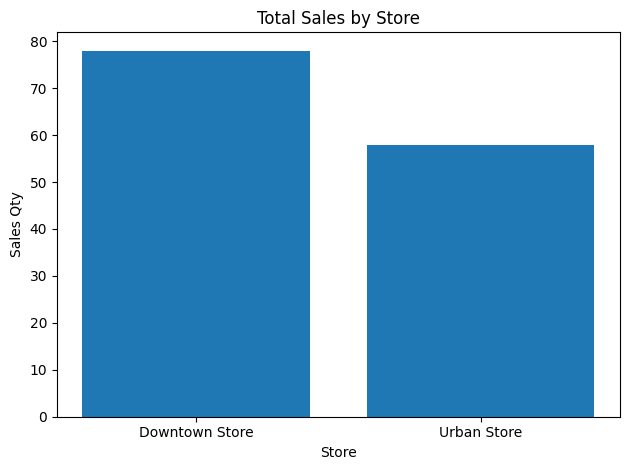

In [4]:
store_perf = (
    weekly_sales_fact.groupby("store_name")["sales_qty"]
    .sum()
    .reset_index()
)

plt.figure()
plt.bar(store_perf["store_name"], store_perf["sales_qty"])

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Sales Qty")

plt.tight_layout()
plt.show()

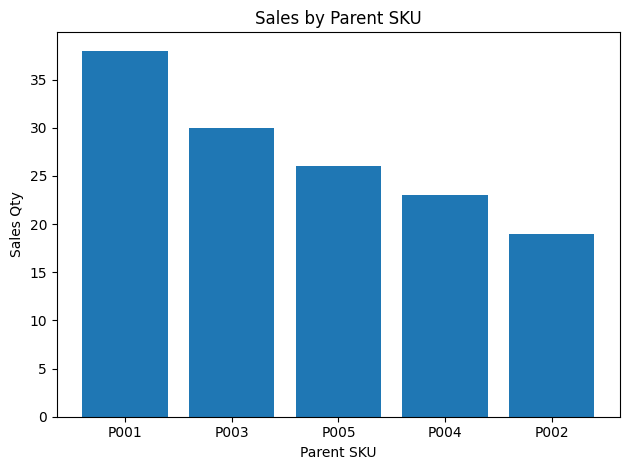

In [5]:
parent_perf = (
    weekly_sales_fact.groupby("parent_sku_id")["sales_qty"]
    .sum()
    .reset_index()
    .sort_values(by="sales_qty", ascending=False)
)

plt.figure()
plt.bar(parent_perf["parent_sku_id"], parent_perf["sales_qty"])

plt.title("Sales by Parent SKU")
plt.xlabel("Parent SKU")
plt.ylabel("Sales Qty")

plt.tight_layout()
plt.show()

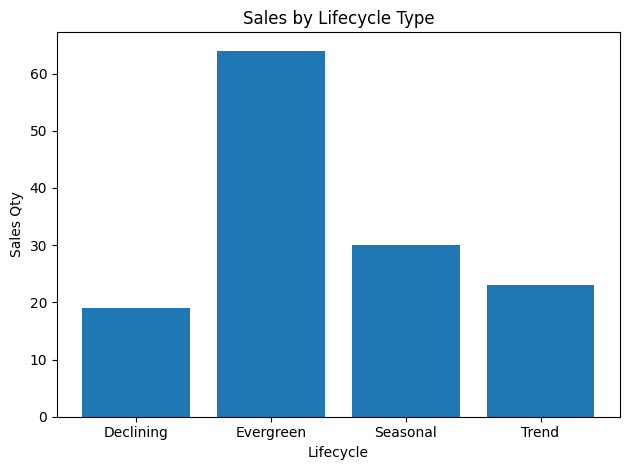

In [6]:
lifecycle_perf = (
    weekly_sales_fact.groupby("lifecycle_type")["sales_qty"]
    .sum()
    .reset_index()
)

plt.figure()
plt.bar(lifecycle_perf["lifecycle_type"], lifecycle_perf["sales_qty"])

plt.title("Sales by Lifecycle Type")
plt.xlabel("Lifecycle")
plt.ylabel("Sales Qty")

plt.tight_layout()
plt.show()

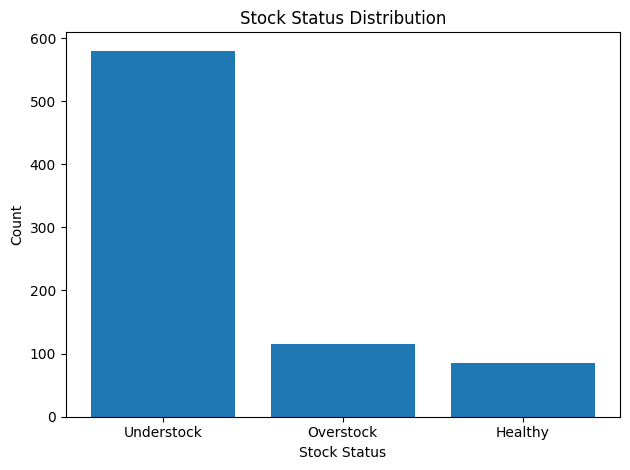

In [7]:
stock_status = (
    replen_support_table["stock_status"]
    .value_counts()
    .reset_index()
)

stock_status.columns = ["stock_status", "count"]

plt.figure()
plt.bar(stock_status["stock_status"], stock_status["count"])

plt.title("Stock Status Distribution")
plt.xlabel("Stock Status")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

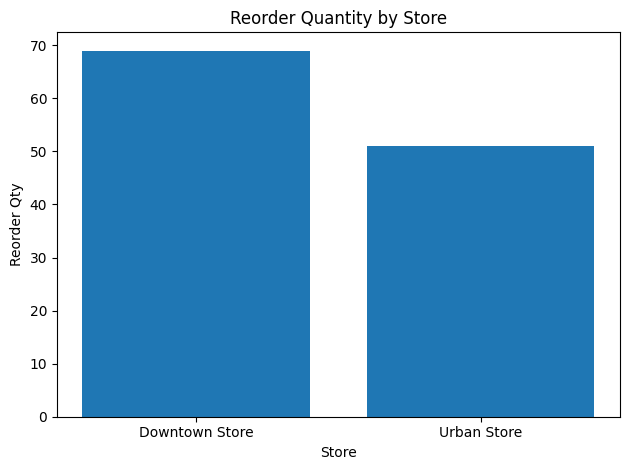

In [8]:
reorder_by_store = (
    replen_support_table.groupby("store_name")["reorder_qty"]
    .sum()
    .reset_index()
)

plt.figure()
plt.bar(reorder_by_store["store_name"], reorder_by_store["reorder_qty"])

plt.title("Reorder Quantity by Store")
plt.xlabel("Store")
plt.ylabel("Reorder Qty")

plt.tight_layout()
plt.show()

In [9]:
product_master_parent.head()

,parent_sku_id,product_name,brand,category,lifecycle_type,base_price,sku_age_weeks,size_variant_count,is_shared_assortment
0,P001,Basic Tee 1,SimuBrand,Apparel,Evergreen,34,7,3,1
1,P002,Relaxed Shirt 2,SimuBrand,Apparel,Declining,55,35,3,1
2,P003,Summer Dress 3,SimuBrand,Apparel,Seasonal,48,21,3,1
3,P004,Classic Polo 4,SimuBrand,Apparel,Trend,33,90,3,1
4,P005,Wide Leg Pants 5,SimuBrand,Apparel,Evergreen,89,15,3,1


In [10]:
weekly_sales_fact.head()

,week_id,week_start_date,week_end_date,week_type,store_id,store_name,parent_sku_id,child_sku_id,lifecycle_type,base_price,sales_qty,sales_value,has_sales
0,W001,2025-01-06,2025-01-12,spike,S001,Downtown Store,P001,P001_S,Evergreen,34,1,34,1
1,W001,2025-01-06,2025-01-12,spike,S001,Downtown Store,P001,P001_M,Evergreen,34,5,170,1
2,W001,2025-01-06,2025-01-12,spike,S001,Downtown Store,P001,P001_L,Evergreen,34,0,0,0
3,W001,2025-01-06,2025-01-12,spike,S001,Downtown Store,P002,P002_S,Declining,55,0,0,0
4,W001,2025-01-06,2025-01-12,spike,S001,Downtown Store,P002,P002_M,Declining,55,2,110,1


In [11]:
product_master_child.head()

,child_sku_id,parent_sku_id,product_name,brand,category,size,base_price,lifecycle_type,sku_age_weeks,variant_type
0,P001_S,P001,Basic Tee 1,SimuBrand,Apparel,S,34,Evergreen,7,Size
1,P001_M,P001,Basic Tee 1,SimuBrand,Apparel,M,34,Evergreen,7,Size
2,P001_L,P001,Basic Tee 1,SimuBrand,Apparel,L,34,Evergreen,7,Size
3,P002_S,P002,Relaxed Shirt 2,SimuBrand,Apparel,S,55,Declining,35,Size
4,P002_M,P002,Relaxed Shirt 2,SimuBrand,Apparel,M,55,Declining,35,Size


In [12]:
import pandas as pd
import plotly.graph_objects as go

# ----------------------------------------
# Join weekly sales with child product info
# ----------------------------------------
sankey_source = weekly_sales_fact.merge(
    product_master_child[["child_sku_id", "size"]],
    on="child_sku_id",
    how="left"
)

# Optional check
print(sankey_source[["store_name", "parent_sku_id", "child_sku_id", "size", "sales_qty"]].head())
print(sankey_source["size"].isnull().sum())

       store_name parent_sku_id child_sku_id size  sales_qty
0  Downtown Store          P001       P001_S    S          1
1  Downtown Store          P001       P001_M    M          5
2  Downtown Store          P001       P001_L    L          0
3  Downtown Store          P002       P002_S    S          0
4  Downtown Store          P002       P002_M    M          2
0


In [13]:
store_parent_df = (
    sankey_source.groupby(["store_name", "parent_sku_id"], as_index=False)["sales_qty"]
    .sum()
)

In [14]:
parent_size_df = (
    sankey_source.groupby(["parent_sku_id", "size"], as_index=False)["sales_qty"]
    .sum()
)

In [15]:
store_labels = store_parent_df["store_name"].drop_duplicates().tolist()
parent_labels = store_parent_df["parent_sku_id"].drop_duplicates().tolist()
size_labels = parent_size_df["size"].drop_duplicates().tolist()

labels = store_labels + parent_labels + size_labels
label_index = {label: i for i, label in enumerate(labels)}

In [16]:
# Store -> Parent
source_1 = store_parent_df["store_name"].map(label_index).tolist()
target_1 = store_parent_df["parent_sku_id"].map(label_index).tolist()
value_1 = store_parent_df["sales_qty"].tolist()

# Parent -> Size
source_2 = parent_size_df["parent_sku_id"].map(label_index).tolist()
target_2 = parent_size_df["size"].map(label_index).tolist()
value_2 = parent_size_df["sales_qty"].tolist()

source = source_1 + source_2
target = target_1 + target_2
value = value_1 + value_2

In [17]:
fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                label=labels
            ),
            link=dict(
                source=source,
                target=target,
                value=value
            )
        )
    ]
)

fig.update_layout(
    title_text="Sales Flow: Store → Parent SKU → Size",
    font_size=10
)

fig.show()

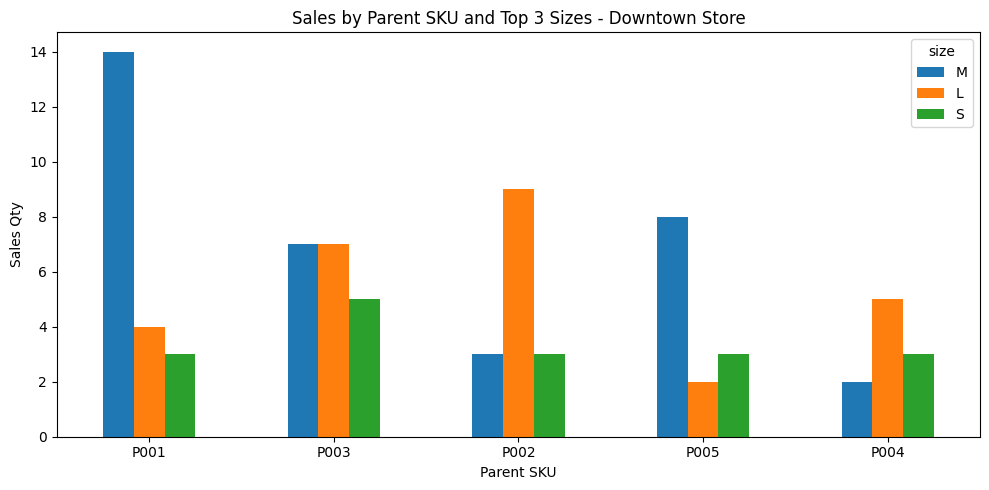

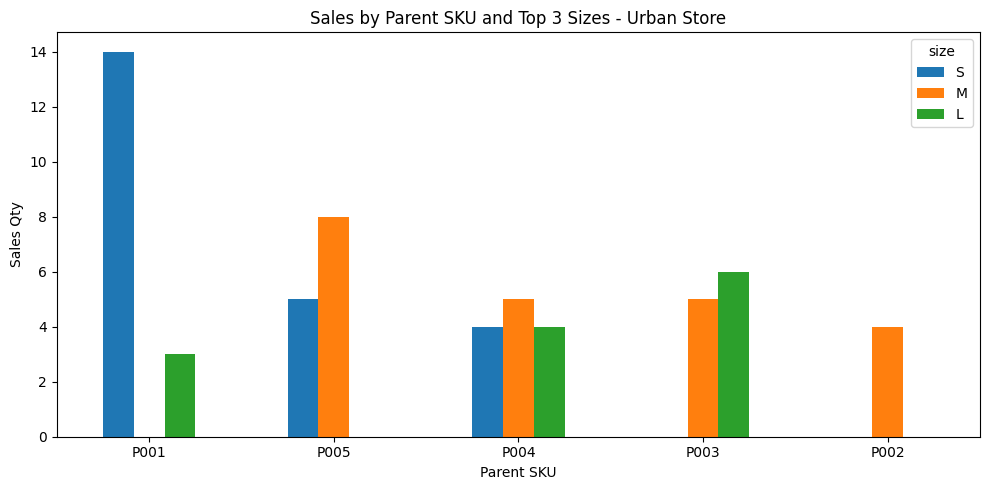

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Prepare source table
# weekly_sales_fact does not have size, so join first
# --------------------------------------------------
chart_df = weekly_sales_fact.merge(
    product_master_child[["child_sku_id", "size"]],
    on="child_sku_id",
    how="left"
)

# --------------------------------------------------
# Aggregate sales by store + parent + size
# --------------------------------------------------
store_parent_size = (
    chart_df.groupby(["store_name", "parent_sku_id", "size"], as_index=False)["sales_qty"]
    .sum()
)

# --------------------------------------------------
# Build one chart per store
# - parent SKU sorted by total qty sold
# - sizes shown as grouped bars
# --------------------------------------------------
store_list = store_parent_size["store_name"].drop_duplicates().tolist()

for store_name in store_list:
    store_data = store_parent_size[store_parent_size["store_name"] == store_name].copy()

    # total qty by parent for sorting
    parent_sort_df = (
        store_data.groupby("parent_sku_id", as_index=False)["sales_qty"]
        .sum()
        .sort_values(by="sales_qty", ascending=False)
    )

    sorted_parents = parent_sort_df["parent_sku_id"].tolist()

    # pivot for grouped bar chart
    plot_df = (
        store_data.pivot_table(
            index="parent_sku_id",
            columns="size",
            values="sales_qty",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    # keep consistent parent order
    plot_df["parent_sku_id"] = pd.Categorical(
        plot_df["parent_sku_id"],
        categories=sorted_parents,
        ordered=True
    )
    plot_df = plot_df.sort_values("parent_sku_id")

    # keep only top 3 sizes by total sold in this store
    size_rank = (
        store_data.groupby("size", as_index=False)["sales_qty"]
        .sum()
        .sort_values(by="sales_qty", ascending=False)
    )

    top_3_sizes = size_rank["size"].head(3).tolist()

    # only keep available size columns
    available_size_cols = [col for col in top_3_sizes if col in plot_df.columns]

    plot_df = plot_df[["parent_sku_id"] + available_size_cols]

    # plot
    plot_df.set_index("parent_sku_id").plot(kind="bar", figsize=(10, 5))

    plt.title(f"Sales by Parent SKU and Top 3 Sizes - {store_name}")
    plt.xlabel("Parent SKU")
    plt.ylabel("Sales Qty")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [19]:
risk_summary = (
    replen_support_table.groupby("parent_sku_id")["stock_status"]
    .value_counts()
    .unstack()
    .fillna(0)
)

risk_summary

stock_status,Healthy,Overstock,Understock
parent_sku_id,,,
P001,19,23,114
P002,18,22,116
P003,18,20,118
P004,13,29,114
P005,17,21,118


In [20]:
replen_support_table["lost_sales_qty"] = (
    replen_support_table["target_stock_qty"] - replen_support_table["on_hand_qty"]
)

replen_support_table["lost_sales_qty"] = replen_support_table["lost_sales_qty"].clip(lower=0)

In [21]:
replen_support_table["excess_stock_qty"] = (
    replen_support_table["on_hand_qty"] - replen_support_table["target_stock_qty"]
)

replen_support_table["excess_stock_qty"] = replen_support_table["excess_stock_qty"].clip(lower=0)

In [22]:
impact_summary = replen_support_table[[
    "lost_sales_qty",
    "excess_stock_qty"
]].sum()

impact_summary

lost_sales_qty      120
excess_stock_qty    165
dtype: int64

In [23]:
decision_summary = (
    replen_support_table["priority_flag"]
    .value_counts()
    .reset_index()
)

decision_summary

,priority_flag,count
0,Normal,614
1,Hold / Monitor,115
2,Reorder Now,51


In [24]:
reorder_by_sku = (
    replen_support_table.groupby("parent_sku_id")["reorder_qty"]
    .sum()
    .reset_index()
    .sort_values(by="reorder_qty", ascending=False)
)

reorder_by_sku

,parent_sku_id,reorder_qty
0,P001,32
2,P003,31
1,P002,21
4,P005,21
3,P004,15
